# COVID-19 CT Image Segmentation

Facundo Bautista Barbera A01066843

Emiliano Camacho Ponce A01712408

Charbel Isaías Chávez Zavala A01711950

Alfredo Alejandro Soto Herrera A01711368

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/covid-segmentation/masks_medseg.npy
/kaggle/input/competitions/covid-segmentation/images_medseg.npy
/kaggle/input/competitions/covid-segmentation/test_images_medseg.npy
/kaggle/input/competitions/covid-segmentation/masks_radiopedia.npy
/kaggle/input/competitions/covid-segmentation/images_radiopedia.npy


Definimos los parámetros iniciales:

- **tamano = (256, 256)**: Resolución a la que se escalarán todas las
  imágenes y máscaras.
- **clases** y **colores**: Nombres y paleta fijos para los 4 canales de las máscaras
  (vidrio esmerilado, consolidación, otros tejidos pulmonares, fondo).
- **salida** Incluye un timestamp único por corrida, para no sobreescribir resultados
  de ejecuciones previas del ETL.

In [2]:
from pathlib import Path
from datetime import datetime
import hashlib

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from IPython.display import display

# Detectamos si estamos en un notebook de Kaggle (existe /kaggle/input) o en local.
es_kaggle = Path("/kaggle/input").exists()


def encontrar_entrada(archivo_ancla="images_medseg.npy", base=Path("/kaggle/input")):
    coincidencias = list(base.rglob(archivo_ancla))
    if not coincidencias:
        raise FileNotFoundError(
            f"No se encontró '{archivo_ancla}' bajo {base}. "
            "Verifica que el dataset esté agregado al notebook (botón 'Add Input' "
            "en el panel derecho de Kaggle)."
        )
    return coincidencias[0].parent


if es_kaggle:
    entrada = encontrar_entrada()
    # /kaggle/input es de solo lectura; /kaggle/working es la única carpeta con
    # permiso de escritura y se conserva como output al hacer "Save & Run All".
    salida = Path("/kaggle/working") / "processed" / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
else:
    carpeta = Path.cwd()
    proyecto = carpeta if carpeta.name == "mini-reto" else carpeta / "mini-reto"
    entrada = proyecto / "data" / "raw"
    salida = proyecto / "data" / "processed" / datetime.now().strftime("%Y%m%d_%H%M%S_%f")

tamano = (256, 256)
clases = ["Vidrio esmerilado", "Consolidación", "Otros tejidos pulmonares", "Fondo"]
colores = ["#f4a261", "#e63946", "#2a9d8f", "#64748b"]
pd.set_option("display.float_format", "{:,.4f}".format)
print("Entorno:", "Kaggle" if es_kaggle else "Local")
print("Entrada:", entrada)
print("Salida:", salida)

Entorno: Kaggle
Entrada: /kaggle/input/competitions/covid-segmentation
Salida: /kaggle/working/processed/20260915_063800_285591


### Validación

- Se exige que todas las imágenes tengan forma `(N, 512, 512, 1)` y que, si existe archivo de máscaras, tenga forma `(N, 512, 512, 4)` mismo número de cortes que su imagen correspondiente. Si no se cumple, se detiene la ejecución.
- Se construye el `inventario` (tamaño en MB, tipo de dato, dimensiones) para diagnóstico.

In [3]:
archivos = {
    "medseg": ("images_medseg.npy", "masks_medseg.npy"),
    "radiopedia": ("images_radiopedia.npy", "masks_radiopedia.npy"),
    "prueba": ("test_images_medseg.npy", None),
}

datos = {}
inventario = []
for fuente, (archivo_imagen, archivo_mascara) in archivos.items():
    imagenes = np.load(entrada / archivo_imagen, mmap_mode="r", allow_pickle=False)
    mascaras = np.load(entrada / archivo_mascara, mmap_mode="r", allow_pickle=False) if archivo_mascara else None
    if imagenes.ndim != 4 or imagenes.shape[1:] != (512, 512, 1):
        raise ValueError(f"Forma inesperada en {archivo_imagen}: {imagenes.shape}")
    if mascaras is not None and mascaras.shape != (*imagenes.shape[:3], 4):
        raise ValueError(f"Las imágenes y máscaras de {fuente} no coinciden")
    datos[fuente] = (imagenes, mascaras)
    for nombre, arreglo in [(archivo_imagen, imagenes), (archivo_mascara, mascaras)]:
        if arreglo is not None:
            inventario.append({"archivo": nombre, "dimensiones": str(arreglo.shape),
                               "tipo": str(arreglo.dtype), "MB": arreglo.nbytes / 1e6})
inventario = pd.DataFrame(inventario)
display(inventario)

,archivo,dimensiones,tipo,MB
0,images_medseg.npy,"(100, 512, 512, 1)",float64,209.7152
1,masks_medseg.npy,"(100, 512, 512, 4)",bool,104.8576
2,images_radiopedia.npy,"(829, 512, 512, 1)",float64,"1,738.5390"
3,masks_radiopedia.npy,"(829, 512, 512, 4)",bool,869.2695
4,test_images_medseg.npy,"(10, 512, 512, 1)",float64,20.9715


### Atributo por atributo

Se calculan por cada corte individual los atributos que luego deciden qué se
conserva y qué se revisa:

- **imagen_finita**: `True` solo si todos los píxeles son finitos.
- **huella_imagen**: Permite detectar duplicados, comparando huellas en vez de arreglos completos.
- **imagen_constante**: Se marca cuando `minimo == maximo`, es decir, un corte sin ningún contraste.
- **Validez de máscara** Una máscara se considera válida si todos sus valores son estrictamente 0 o 1, y si la suma de los 3 canales de lesión (vidrio esmerilado, consolidación, otros tejidos) por píxel es ≤ 1. El canal de fondo se excluye de esta regla de porque puede venir inconsistente con las otras tres clases.
- **pixeles_fondo_inconsistente**: Cuenta cuántos píxeles del canal de fondo original no coinciden con el complemento lógico de las otras tres clases. Esta inconsistencia solo se documenta. 
- **proporcion_lesion**: Suma de las proporciones de las clases 0 y 1 (vidrio esmerilado + consolidación).

In [4]:
registros = []
for fuente, (imagenes, mascaras) in datos.items():
    for indice in range(len(imagenes)):
        imagen = imagenes[indice, ..., 0]
        finita = bool(np.isfinite(imagen).all())
        registro = {
            "id": f"{fuente}_{indice:04d}", "fuente": fuente, "indice": indice,
            "imagen_finita": finita,
            "minimo": float(imagen.min()) if finita else np.nan,
            "maximo": float(imagen.max()) if finita else np.nan,
            "media": float(imagen.mean()) if finita else np.nan,
            "desviacion": float(imagen.std()) if finita else np.nan,
            "huella_imagen": hashlib.sha256(imagen.tobytes()).hexdigest(),
            "huella_mascara": None, "mascara_valida": None, "pixeles_fondo_inconsistente": 0,
        }
        for clase in range(4):
            registro[f"proporcion_{clase}"] = np.nan
        if mascaras is not None:
            mascara = mascaras[indice]
            valida = bool(np.isin(mascara, [0, 1]).all() and (mascara[..., :3].sum(axis=-1) <= 1).all())
            fondo_esperado = ~mascara[..., :3].any(axis=-1)
            registro["pixeles_fondo_inconsistente"] = int((mascara[..., 3] != fondo_esperado).sum())
            registro["mascara_valida"] = valida
            registro["huella_mascara"] = hashlib.sha256(mascara.tobytes()).hexdigest()
            if valida:
                for clase in range(4):
                    registro[f"proporcion_{clase}"] = float(mascara[..., clase].mean())
        registros.append(registro)

auditoria = pd.DataFrame(registros)
auditoria["proporcion_lesion"] = auditoria.proporcion_0 + auditoria.proporcion_1
auditoria["imagen_constante"] = auditoria.minimo == auditoria.maximo
display(auditoria.head())
display(auditoria.groupby("fuente")[["minimo", "maximo", "media", "desviacion"]].agg(["min", "median", "max"]).rename(
    columns={"min": "mínimo", "median": "mediana", "max": "máximo"}))
display(pd.Series({
    "Imágenes no finitas": int((~auditoria.imagen_finita).sum()),
    "Imágenes constantes": int(auditoria.imagen_constante.sum()),
    "Máscaras inválidas": int((auditoria.mascara_valida == False).sum()),
    "Máscaras con fondo inconsistente": int((auditoria.pixeles_fondo_inconsistente > 0).sum()),
    "Imágenes repetidas adicionales": int(auditoria.huella_imagen.duplicated().sum()),
}, name="Cantidad"))

,id,fuente,indice,imagen_finita,minimo,maximo,media,desviacion,huella_imagen,huella_mascara,mascara_valida,pixeles_fondo_inconsistente,proporcion_0,proporcion_1,proporcion_2,proporcion_3,proporcion_lesion,imagen_constante
0,medseg_0000,medseg,0,True,"-1,414.8936",212.7660,-627.1349,575.8760,c617bfb0f85dc5f4b22023aab18fa54d90b323ada259f5...,ad5987b6a0018de8f227b3ec43e3b9553b1f174c95c726...,True,0,0.0310,0.1055,0.0207,0.8428,0.1365,False
1,medseg_0001,medseg,1,True,"-1,477.6923",278.5918,-528.5524,461.9249,2e4d85e6b55306685e2c3f84ad3a114fade1da1e46f696...,737bac85304236487300760b15e1e55dd404c522ffe2e3...,True,0,0.0763,0.1430,0.1465,0.6342,0.2193,False
2,medseg_0002,medseg,2,True,"-1,070.7746",272.2490,-550.2367,462.7275,af14838d15a6f416c599ece845bf5f64d7e84ada5a19a5...,57ee6a53d42b56c889e27018aee571b04f74c8e3052bd4...,True,0,0.0031,0.0000,0.2121,0.7848,0.0031,False
3,medseg_0003,medseg,3,True,"-1,146.9388",267.3469,-576.8326,474.6491,6e450f532a9d18c35291240332d6aef10722df73350098...,aa964e1cbb83232a4a3068f2dbc3427a08dbb2696b3fc2...,True,0,0.0387,0.0230,0.0846,0.8537,0.0617,False
4,medseg_0004,medseg,4,True,"-1,061.5379",262.0646,-348.6632,402.1301,f69f1e777ca706b8cf89774315eeda3b6f7cb838074a46...,e286ce61788bb027b5c6eb7b8656e3b0c857a921f2b59f...,True,0,0.0248,0.0000,0.4337,0.5415,0.0248,False


minimo                           maximo                    \
                mínimo     mediana      máximo   mínimo  mediana   máximo   
fuente                                                                      
medseg     -1,606.5217 -1,202.6395   -999.0604  14.3344 252.8176 597.8047   
prueba     -1,450.0000 -1,206.6631 -1,037.6594 177.8523 302.1923 875.6456   
radiopedia -1,414.7654 -1,334.5728 -1,151.7725 136.5284 136.5284 291.0408   

                 media                     desviacion                    
                mínimo   mediana    máximo     mínimo  mediana   máximo  
fuente                                                                   
medseg     -1,021.4200 -412.8645 -123.8465   217.4706 455.8552 604.8113  
prueba       -704.4954 -372.2518 -160.2301   399.1624 465.7566 574.6290  
radiopedia   -649.9664 -474.9098 -105.6649   339.6310 486.5277 534.9848

Imágenes no finitas                   0
Imágenes constantes                   0
Máscaras inválidas                    0
Máscaras con fondo inconsistente    279
Imágenes repetidas adicionales        0
Name: Cantidad, dtype: int64

Graficamos las distribuciones a partir de los atributos calculados en la celda anterior.

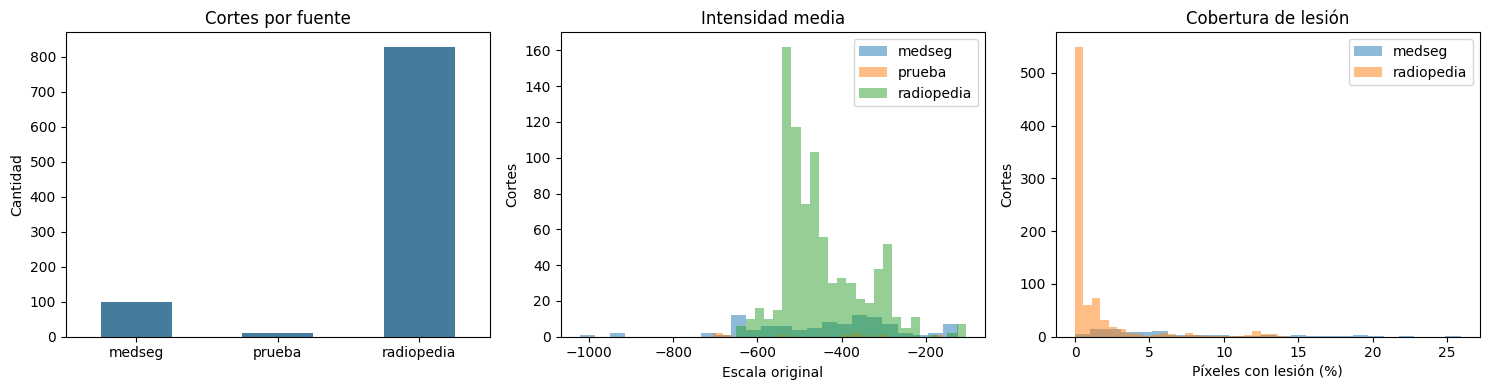

In [5]:
figura, ejes = plt.subplots(1, 3, figsize=(15, 4))
auditoria.groupby("fuente").size().plot.bar(ax=ejes[0], color="#457b9d", rot=0)
ejes[0].set(title="Cortes por fuente", xlabel="", ylabel="Cantidad")
for fuente, grupo in auditoria.groupby("fuente"):
    ejes[1].hist(grupo.media.dropna(), bins=25, alpha=0.5, label=fuente)
    if fuente != "prueba":
        ejes[2].hist(grupo.proporcion_lesion.dropna() * 100, bins=25, alpha=0.5, label=fuente)
ejes[1].set(title="Intensidad media", xlabel="Escala original", ylabel="Cortes")
ejes[2].set(title="Cobertura de lesión", xlabel="Píxeles con lesión (%)", ylabel="Cortes")
ejes[1].legend()
ejes[2].legend()
plt.tight_layout()
plt.show()


Se calcula el porcentaje de píxeles por clase, simplemente para checar el balance de clases.

,Vidrio esmerilado,Consolidación,Otros tejidos pulmonares,Fondo
fuente,,,,
medseg,4.5641,2.2477,19.9857,73.2044
radiopedia,1.0211,0.2284,14.4977,84.2630


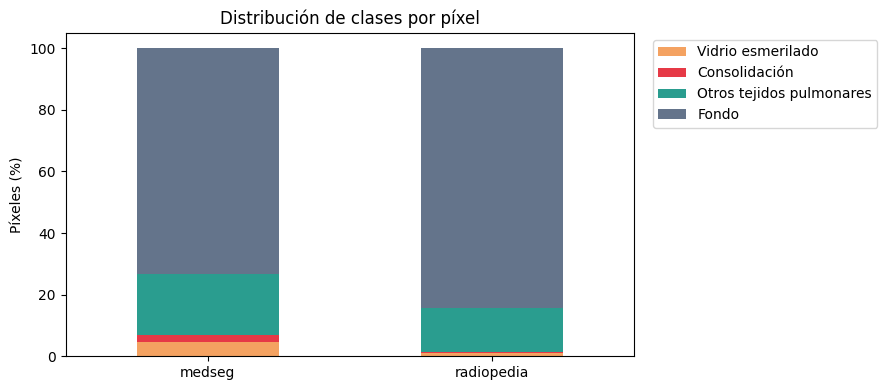

,cortes,sin_lesion,cobertura_mediana
fuente,,,
medseg,100,1,0.0473
radiopedia,829,457,0.0000


In [6]:
mascaras_validas = auditoria[auditoria.mascara_valida == True]
columnas_clase = [f"proporcion_{clase}" for clase in range(4)]
balance_clases = mascaras_validas.groupby("fuente")[columnas_clase].mean() * 100
balance_clases.columns = clases
display(balance_clases)
balance_clases.plot.bar(stacked=True, color=colores, figsize=(9, 4), rot=0)
plt.title("Distribución de clases por píxel")
plt.ylabel("Píxeles (%)")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
display(mascaras_validas.groupby("fuente").agg(
    cortes=("id", "size"),
    sin_lesion=("proporcion_lesion", lambda valores: int((valores == 0).sum())),
    cobertura_mediana=("proporcion_lesion", "median"),
))


Se seleccionan cortes representativos (mínima, mediana y máxima proporción de lesión
por fuente) solo para su inspección visual.

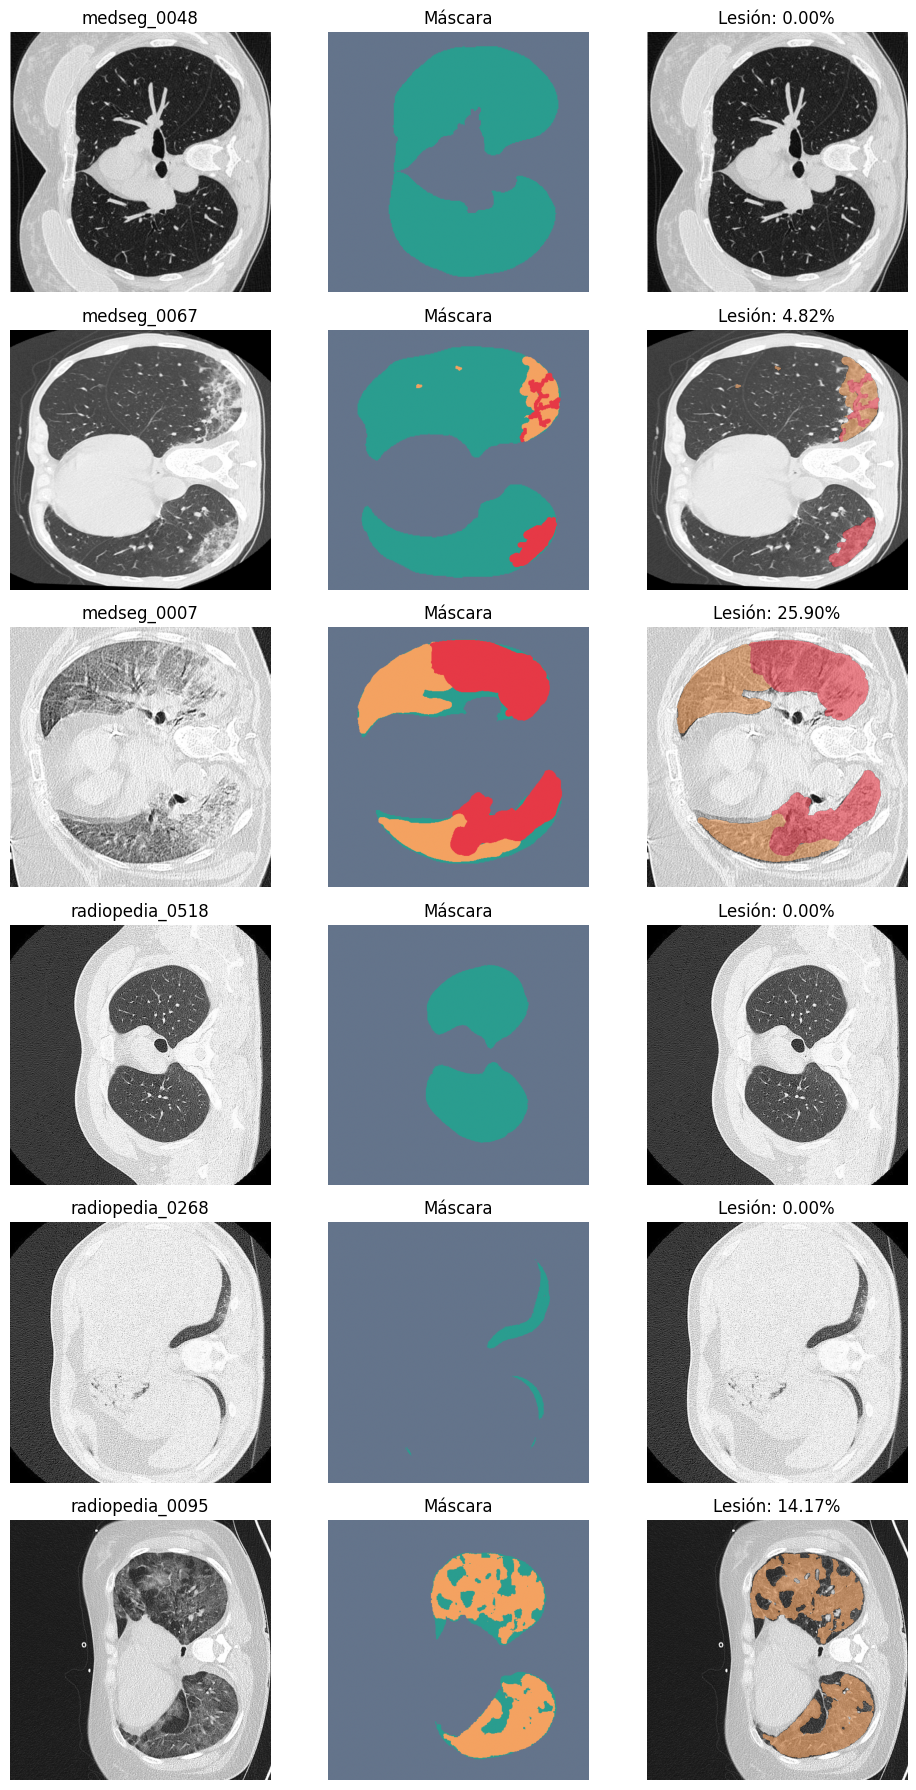

In [7]:
muestras = []
for fuente, grupo in mascaras_validas[mascaras_validas.imagen_finita].groupby("fuente"):
    ordenados = grupo.sort_values("proporcion_lesion")
    posiciones = np.unique([0, len(ordenados) // 2, len(ordenados) - 1])
    muestras.extend(ordenados.iloc[posiciones].to_dict("records"))

if muestras:
    figura, ejes = plt.subplots(len(muestras), 3, figsize=(10, 3 * len(muestras)), squeeze=False)
    for fila, registro in zip(ejes, muestras):
        imagenes, mascaras = datos[registro["fuente"]]
        imagen = imagenes[registro["indice"], ..., 0]
        etiquetas = mascaras[registro["indice"]].argmax(axis=-1)
        fila[0].imshow(imagen, cmap="gray")
        fila[1].imshow(etiquetas, cmap=ListedColormap(colores), vmin=0, vmax=3)
        fila[2].imshow(imagen, cmap="gray")
        fila[2].imshow(np.ma.masked_where(etiquetas >= 2, etiquetas),
                       cmap=ListedColormap(colores[:2]), vmin=0, vmax=1, alpha=0.6)
        fila[0].set_title(registro["id"])
        fila[1].set_title("Máscara")
        fila[2].set_title(f"Lesión: {registro['proporcion_lesion']:.2%}")
        for eje in fila:
            eje.axis("off")
    plt.tight_layout()
    plt.show()

### Reglas de exclusión

Decidimos corte por corte, si se conserva o se excluye. Se evalúan, en este orden, los siguientes motivos:

1. **Imagen no finita**: Contiene NaN/Inf.
2. **Imagen constante**: Sin variación de intensidad (`minimo == maximo`).
3. **Máscara inválida**: no cumple la regla de validez definida anteriormente.
4. **Anotaciones diferentes para la misma imagen**: La misma imagen aparece en el dataset etiquetado con más de una máscara distinta.
5. **Imagen presente en prueba**: El hash de una imagen etiquetada coincide con el hash de alguna imagen del conjunto de prueba. Esto para evitar data leakage.
6. **Par repetido**: El par hash imagen y hash máscara, apareció anteriormente.

El resultado se guarda en dos columnas nuevas: `motivo` (texto concatenado de los
problemas encontrados) y `estado` (`"conservar"` si no hubo ningún motivo, `"revisar"`
en caso contrario). `limpios` es el subconjunto final con `estado == "conservar"`.

In [8]:
etiquetados = auditoria[auditoria.fuente != "prueba"]
anotaciones = etiquetados.groupby("huella_imagen").huella_mascara.nunique()
conflictos = set(anotaciones[anotaciones > 1].index)
huellas_prueba = set(auditoria.loc[auditoria.fuente == "prueba", "huella_imagen"])

motivos = []
pares_vistos = set()
for registro in auditoria.itertuples():
    problemas = []
    if not registro.imagen_finita:
        problemas.append("imagen no finita")
    if registro.imagen_constante:
        problemas.append("imagen constante")
    if registro.fuente != "prueba":
        if not registro.mascara_valida:
            problemas.append("máscara inválida")
        if registro.huella_imagen in conflictos:
            problemas.append("anotaciones diferentes para la misma imagen")
        if registro.huella_imagen in huellas_prueba:
            problemas.append("imagen presente en prueba")
        par = (registro.huella_imagen, registro.huella_mascara)
        if not problemas:
            if par in pares_vistos:
                problemas.append("par repetido")
            else:
                pares_vistos.add(par)
    motivos.append("; ".join(problemas))

auditoria["motivo"] = motivos
auditoria["estado"] = np.where(auditoria.motivo == "", "conservar", "revisar")
limpios = auditoria[auditoria.estado == "conservar"].copy()
display(pd.crosstab(auditoria.fuente, auditoria.estado))
display(auditoria.loc[auditoria.estado == "revisar", ["id", "motivo"]])


estado,conservar
fuente,
medseg,100
prueba,10
radiopedia,829


,id,motivo


### Verificación post-limpieza

- Se documenta el efecto de la limpieza, por ejemplo, cuántos cortes había por fuente originalmente contra cuántos se conservaron.
- Verificaciones explícitas sobre el subconjunto etiquetado limpio, que convierten las reglas de la celda anterior en garantías, en lugar de solo heurísticas aplicadas una vez:
  1. Quedó al menos un par imagen-máscara válido.
  2. No quedan imágenes duplicadas por hash entre los cortes etiquetados conservados.
  3. Ninguna imagen etiquetada conservada coincide (por hash) con una imagen del
     conjunto de prueba.

Si cualquiera de estas condiciones fallara, la ejecución se detendría aquí.

In [9]:
balance_limpieza = auditoria.groupby("fuente").size().to_frame("originales")
balance_limpieza["conservados"] = limpios.groupby("fuente").size().reindex(balance_limpieza.index, fill_value=0)
balance_limpieza["apartados"] = balance_limpieza.originales - balance_limpieza.conservados
display(balance_limpieza)
display(limpios.groupby("fuente")[["media", "desviacion", "proporcion_lesion"]].describe().rename(columns={
    "count": "cantidad", "mean": "promedio", "std": "desviación", "min": "mínimo", "max": "máximo"}))

pares_limpios = limpios[limpios.fuente != "prueba"]
assert len(pares_limpios) > 0, "No quedaron pares válidos"
assert not pares_limpios.huella_imagen.duplicated().any(), "Quedaron imágenes repetidas"
assert not set(pares_limpios.huella_imagen) & huellas_prueba, "Hay coincidencias con la prueba"


,originales,conservados,apartados
fuente,,,
medseg,100,100,0
prueba,10,10,0
radiopedia,829,829,0


media                                                       \
           cantidad  promedio desviación      mínimo       25%       50%   
fuente                                                                     
medseg     100.0000 -443.2362   177.2884 -1,021.4200 -576.3574 -412.8645   
prueba      10.0000 -453.0953   189.3254   -704.4954 -643.7426 -372.2518   
radiopedia 829.0000 -450.6814    96.2648   -649.9664 -520.5753 -474.9098   

                               desviacion           ...                    \
                 75%    máximo   cantidad promedio  ...      75%   máximo   
fuente                                              ...                     
medseg     -325.8640 -123.8465   100.0000 456.3977  ... 499.3177 604.8113   
prueba     -349.3478 -160.2301    10.0000 471.2789  ... 474.6914 574.6290   
radiopedia -397.1802 -105.6649   829.0000 485.2760  ... 498.2045 534.9848   

           proporcion_lesion                                                  \
                    cantidad promedio desviación mínimo    25%    50%    75%   
fuente                                                                         
medseg              100.0000   0.0681     0.0608 0.0000 0.0246 0.0473 0.0942   
prueba                0.0000      NaN        NaN    NaN    NaN    NaN    NaN   
radiopedia          829.0000   0.0125     0.0275 0.0000 0.0000 0.0000 0.0126   

                   
           máximo  
fuente             
medseg     0.2590  
prueba        NaN  
radiopedia 0.1417  

[3 rows x 24 columns]

### Transformaciones

**Transformación de la imagen:**
1. Conversión a `float64` antes de empezar, para evitar perdida de precisión durante la normalización.
2. Normalización min-max por imagen individual: `(imagen - imagen.min()) / (imagen.max() - imagen.min())`.
3. Conversión a `float32` tras normalizar, para reducir el tamaño de almacenamiento a la mitad respecto al `float64`.
4. Redimensionamiento a 256×256 con interpolación bilineal.
5. `np.clip(imagen, 0, 1)` después del resize para corrigir el posible overshoot que puede introducir la interpolación bilineal en bordes de alto contraste.
6. Expansión de dimensión de canal para dejar la forma final en (256, 256, 1).

**Transformación de la máscara:**
1. Conversión a `uint8` con copia, para no alterar el arreglo `bool` original.
2. Recalculamos el canal de fondo como el complemento logico de los tres canales de lesión (`mascara[...,3] = ~mascara[...,:3].any(axis=-1)`). Esto para que el fondo nunca se tome del dato en crudo y siempre se derive de las otras tres clases.
3. Redimensionamiento a 256×256, se usa nearest-neighbor porque la máscara es categórica.
4. No se normaliza la máscara y la mantenemos en 0/1 `uint8`, pues representa presencia/ausencia de clase, no una magnitud continua.

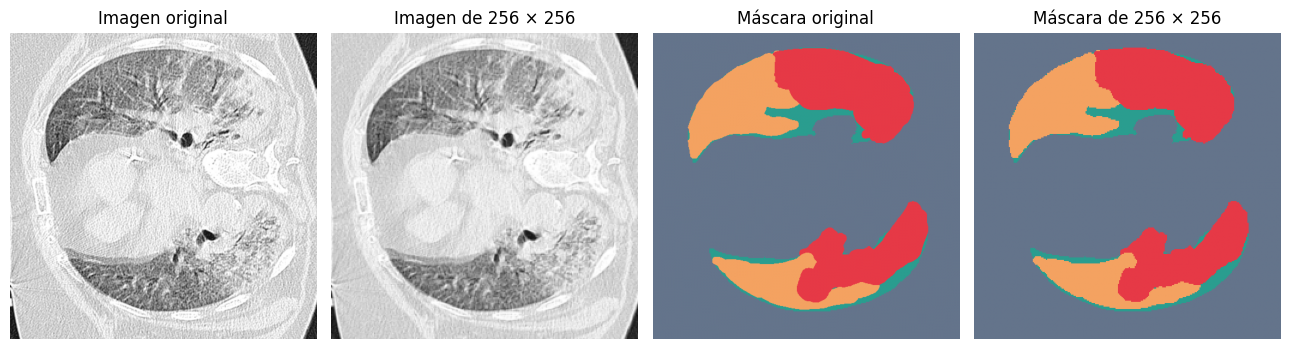

In [10]:
def transformar(imagen, mascara=None):
    imagen = imagen.astype(np.float64)
    imagen = ((imagen - imagen.min()) / (imagen.max() - imagen.min())).astype(np.float32)
    imagen = np.asarray(Image.fromarray(imagen).resize(tamano, Image.Resampling.BILINEAR))
    imagen = np.clip(imagen, 0, 1)[..., None]
    if mascara is not None:
        mascara = mascara.astype(np.uint8).copy()
        mascara[..., 3] = ~mascara[..., :3].any(axis=-1)
        mascara = np.stack([
            np.asarray(Image.fromarray(mascara[..., clase].astype(np.uint8)).resize(
                tamano, Image.Resampling.NEAREST)) for clase in range(4)
        ], axis=-1)
    return imagen, mascara

registro = pares_limpios.sort_values("proporcion_lesion", ascending=False).iloc[0]
imagenes, mascaras = datos[registro.fuente]
imagen_original = imagenes[int(registro.indice), ..., 0]
mascara_original = mascaras[int(registro.indice)]
imagen_nueva, mascara_nueva = transformar(imagen_original, mascara_original)

figura, ejes = plt.subplots(1, 4, figsize=(13, 4))
ejes[0].imshow(imagen_original, cmap="gray")
ejes[1].imshow(imagen_nueva[..., 0], cmap="gray", vmin=0, vmax=1)
ejes[2].imshow(mascara_original.argmax(-1), cmap=ListedColormap(colores), vmin=0, vmax=3)
ejes[3].imshow(mascara_nueva.argmax(-1), cmap=ListedColormap(colores), vmin=0, vmax=3)
for eje, titulo in zip(ejes, ["Imagen original", "Imagen de 256 × 256", "Máscara original", "Máscara de 256 × 256"]):
    eje.set_title(titulo)
    eje.axis("off")
plt.tight_layout()
plt.show()


- Se aplica `transformar` a todos los cortes en `limpios` que ya esten filtrados, y se
  guarda cada corte como un `.npz` comprimido independiente. Si el corte no tiene
  máscara, se guarda solo la imagen.
- **Partición**: Se marca "prueba oficial" para cortes sin máscara, o "pendiente de identificar pacientes" para los que sí tienen máscara.
- **proporcion_final_{clase}**: Proporción de píxeles por clase recalculada después del resize, para poder comparar contra la proporción original y ver cuánto cambia la cobertura de cada clase por el redimensionamiento.
- **pierde_clase_lesion**: Se marca `True` si alguna clase de lesión (0 o 1) tenía proporción > 0 antes del resize pero termina con 0 píxeles después de él, es decir, detecta si el downsampling mas el nearest-neighbor hizo desaparecer por completo una lesión pequeña.
- Guardamos tambien `auditoria.csv`, `inventario.csv`, `manifiesto.csv` y
  `balance_limpieza.csv` para llevar un registro de todas las decisiones anteriores.

In [11]:
salida.mkdir(parents=True, exist_ok=False)
resultados = []
for registro in limpios.itertuples(index=False):
    imagenes, mascaras = datos[registro.fuente]
    imagen = imagenes[registro.indice, ..., 0]
    mascara = mascaras[registro.indice] if mascaras is not None else None
    imagen, mascara = transformar(imagen, mascara)
    archivo = f"{registro.id}.npz"
    if mascara is None:
        np.savez_compressed(salida / archivo, imagen=imagen)
    else:
        np.savez_compressed(salida / archivo, imagen=imagen, mascara=mascara)
    resultado = registro._asdict()
    resultado["archivo"] = archivo
    resultado["particion"] = "prueba oficial" if mascara is None else "pendiente de identificar pacientes"
    for clase in range(4):
        resultado[f"proporcion_final_{clase}"] = float(mascara[..., clase].mean()) if mascara is not None else np.nan
    resultado["pierde_clase_lesion"] = bool(mascara is not None and any(
        resultado[f"proporcion_{clase}"] > 0 and mascara[..., clase].sum() == 0 for clase in (0, 1)))
    resultados.append(resultado)

manifiesto = pd.DataFrame(resultados)
auditoria.to_csv(salida / "auditoria.csv", index=False)
inventario.to_csv(salida / "inventario.csv", index=False)
manifiesto.to_csv(salida / "manifiesto.csv", index=False)
balance_limpieza.to_csv(salida / "balance_limpieza.csv")
print("Carpeta de resultados:", salida)


Carpeta de resultados: /kaggle/working/processed/20260915_063800_285591


### Verificación final

Cada archivo `.npz` generado se vuelve a abrir y se verifica con `assert`
que las decisiones de transformación se cumplieron realmente en el archivo final:

- Imagen con forma (256, 256, 1), tipo `float32`, todos los valores finitos y dentro de [0, 1].
- Máscara con forma (256, 256, 4), tipo `uint8`, todos los valores en {0, 1}, y suma de los 4 canales igual a 1 en cada píxel.
- Para el set de prueba, se confirma que el `.npz` contiene únicamente la clave "imagen" sin la máscara.
- Se calcula `cambio_cobertura.csv` que es la diferencia en puntos porcentuales entre la proporción de cada clase antes y después de la transformación.
- `resumen.json` consolida las cifras clave de todo el proceso de limpieza y
  transformación (cortes originales, conservados, apartados, máscaras de fondo
  corregidas, píxeles corregidos, cortes sin lesión, cortes que pierden alguna clase).

In [12]:
for registro in manifiesto.itertuples():
    with np.load(salida / registro.archivo, allow_pickle=False) as archivo:
        imagen = archivo["imagen"]
        assert imagen.shape == (256, 256, 1)
        assert imagen.dtype == np.float32
        assert np.isfinite(imagen).all() and 0 <= imagen.min() <= imagen.max() <= 1
        if registro.fuente != "prueba":
            mascara = archivo["mascara"]
            assert mascara.shape == (256, 256, 4) and mascara.dtype == np.uint8
            assert np.isin(mascara, [0, 1]).all() and (mascara.sum(axis=-1) == 1).all()
        else:
            assert archivo.files == ["imagen"]
assert len(list(salida.glob("*.npz"))) == len(limpios)

cambios = pd.DataFrame({clases[clase]:
    (manifiesto[f"proporcion_final_{clase}"] - manifiesto[f"proporcion_{clase}"]) * 100
    for clase in range(4)})
display(cambios.agg(["mean", "min", "max"]).rename(index={"mean": "promedio", "min": "mínimo", "max": "máximo"}))
cambios.to_csv(salida / "cambio_cobertura.csv", index=False)
resumen = pd.Series({
    "Cortes originales": len(auditoria),
    "Cortes etiquetados conservados": len(pares_limpios),
    "Cortes de prueba conservados": int((limpios.fuente == "prueba").sum()),
    "Cortes apartados": int((auditoria.estado == "revisar").sum()),
    "Máscaras con fondo corregido": int((limpios.pixeles_fondo_inconsistente > 0).sum()),
    "Píxeles de fondo corregidos": int(limpios.pixeles_fondo_inconsistente.sum()),
    "Cortes conservados sin lesión": int((pares_limpios.proporcion_lesion == 0).sum()),
    "Cortes que pierden alguna clase de lesión": int(manifiesto.pierde_clase_lesion.sum()),
}, name="Cantidad")
resumen.to_json(salida / "resumen.json", force_ascii=False, indent=2)
display(resumen)
print("Verificación de archivos completada")


,Vidrio esmerilado,Consolidación,Otros tejidos pulmonares,Fondo
promedio,0.0002,-0.0001,0.0031,-0.0124
mínimo,-0.0530,-0.0294,-0.1217,-0.4353
máximo,0.0351,0.0240,0.1774,0.1240


Cortes originales                              939
Cortes etiquetados conservados                 929
Cortes de prueba conservados                    10
Cortes apartados                                 0
Máscaras con fondo corregido                   279
Píxeles de fondo corregidos                  22537
Cortes conservados sin lesión                  458
Cortes que pierden alguna clase de lesión        5
Name: Cantidad, dtype: int64

Verificación de archivos completada


## Modelo

## Introducción

El objetivo es construir un modelo que, dada una imagen de CT, genere una máscara de 4 canales que localice con precisión las lesiones asociadas a COVID-19. 

### ETL realizado
Las secciones anteriores de este mismo notebook hacen la limpieza y transformación de los `.npy` originales (`images_medseg`, `masks_medseg`, `images_radiopedia`, `masks_radiopedia`, `test_images_medseg`) hacia archivos `.npz` individuales, uno por corte.

Lo siguiente a realizar será:

- Un `Dataset`/`DataLoader` de PyTorch que consume directamente los `.npz` del ETL.
- Una arquitectura U-Net (con opción de backbone ResNet) para segmentación.
- Un ciclo de entrenamiento con pérdida combinada Dice + Entropía Cruzada, optimizador Adam, early stopping y checkpointing del mejor modelo.
- Evaluación cuantitativa (Dice y IoU por clase) y cualitativa (comparación visual contra el ground truth).
- Se entrena una configuración base (solo entropía cruzada, sin regularización) y una refinada (aumentos, dropout, decaimiento de pesos y pérdida Dice) con la misma partición y semilla.

Definimos semillas y el dispositivo de cómputo.

In [13]:
import json
import math
import random
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# os, Path, numpy, pandas, matplotlib.pyplot y ListedColormap ya se importaron
# en las celdas del ETL, arriba en este mismo notebook.

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.cuda.manual_seed_all(SEMILLA)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Dispositivo:", dispositivo)
if dispositivo.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Aviso: no se detectó GPU. En Kaggle, activa un acelerador en "
          "Settings → Accelerator (p. ej. GPU T4 x2) antes de entrenar.")

# Reutilizamos directamente la carpeta de salida del ETL (celdas de arriba en este
# mismo notebook): ahí ya quedaron el manifiesto.csv y los .npz por corte.
ruta_procesado = salida
TAMANO = tamano  # (256, 256), ya definido en la celda de parámetros del ETL
# clases y colores también ya están definidos arriba, en la celda de parámetros del ETL.

Dispositivo: cuda
GPU: Tesla T4


Tras la limpieza, del total de 939 cortes originales se conservaron 929 cortes etiquetados y 10 de prueba (0 apartados por forma/calidad). `manifiesto.csv` es nuestra fuente de verdad para el resto de este notebook.

In [14]:
manifiesto = pd.read_csv(ruta_procesado / "manifiesto.csv")
print("Cortes en el manifiesto:", len(manifiesto))
display(manifiesto.head())
display(manifiesto["fuente"].value_counts())

Cortes en el manifiesto: 939


,id,fuente,indice,imagen_finita,minimo,maximo,media,desviacion,huella_imagen,huella_mascara,...,imagen_constante,motivo,estado,archivo,particion,proporcion_final_0,proporcion_final_1,proporcion_final_2,proporcion_final_3,pierde_clase_lesion
0,medseg_0000,medseg,0,True,"-1,414.8936",212.7660,-627.1349,575.8760,c617bfb0f85dc5f4b22023aab18fa54d90b323ada259f5...,ad5987b6a0018de8f227b3ec43e3b9553b1f174c95c726...,...,False,NaN,conservar,medseg_0000.npz,pendiente de identificar pacientes,0.0311,0.1055,0.0204,0.8429,False
1,medseg_0001,medseg,1,True,"-1,477.6923",278.5918,-528.5524,461.9249,2e4d85e6b55306685e2c3f84ad3a114fade1da1e46f696...,737bac85304236487300760b15e1e55dd404c522ffe2e3...,...,False,NaN,conservar,medseg_0001.npz,pendiente de identificar pacientes,0.0764,0.1429,0.1470,0.6338,False
2,medseg_0002,medseg,2,True,"-1,070.7746",272.2490,-550.2367,462.7275,af14838d15a6f416c599ece845bf5f64d7e84ada5a19a5...,57ee6a53d42b56c889e27018aee571b04f74c8e3052bd4...,...,False,NaN,conservar,medseg_0002.npz,pendiente de identificar pacientes,0.0031,0.0000,0.2120,0.7849,False
3,medseg_0003,medseg,3,True,"-1,146.9388",267.3469,-576.8326,474.6491,6e450f532a9d18c35291240332d6aef10722df73350098...,aa964e1cbb83232a4a3068f2dbc3427a08dbb2696b3fc2...,...,False,NaN,conservar,medseg_0003.npz,pendiente de identificar pacientes,0.0388,0.0232,0.0851,0.8530,False
4,medseg_0004,medseg,4,True,"-1,061.5379",262.0646,-348.6632,402.1301,f69f1e777ca706b8cf89774315eeda3b6f7cb838074a46...,e286ce61788bb027b5c6eb7b8656e3b0c857a921f2b59f...,...,False,NaN,conservar,medseg_0004.npz,pendiente de identificar pacientes,0.0250,0.0000,0.4339,0.5412,False


fuente
radiopedia    829
medseg        100
prueba         10
Name: count, dtype: int64

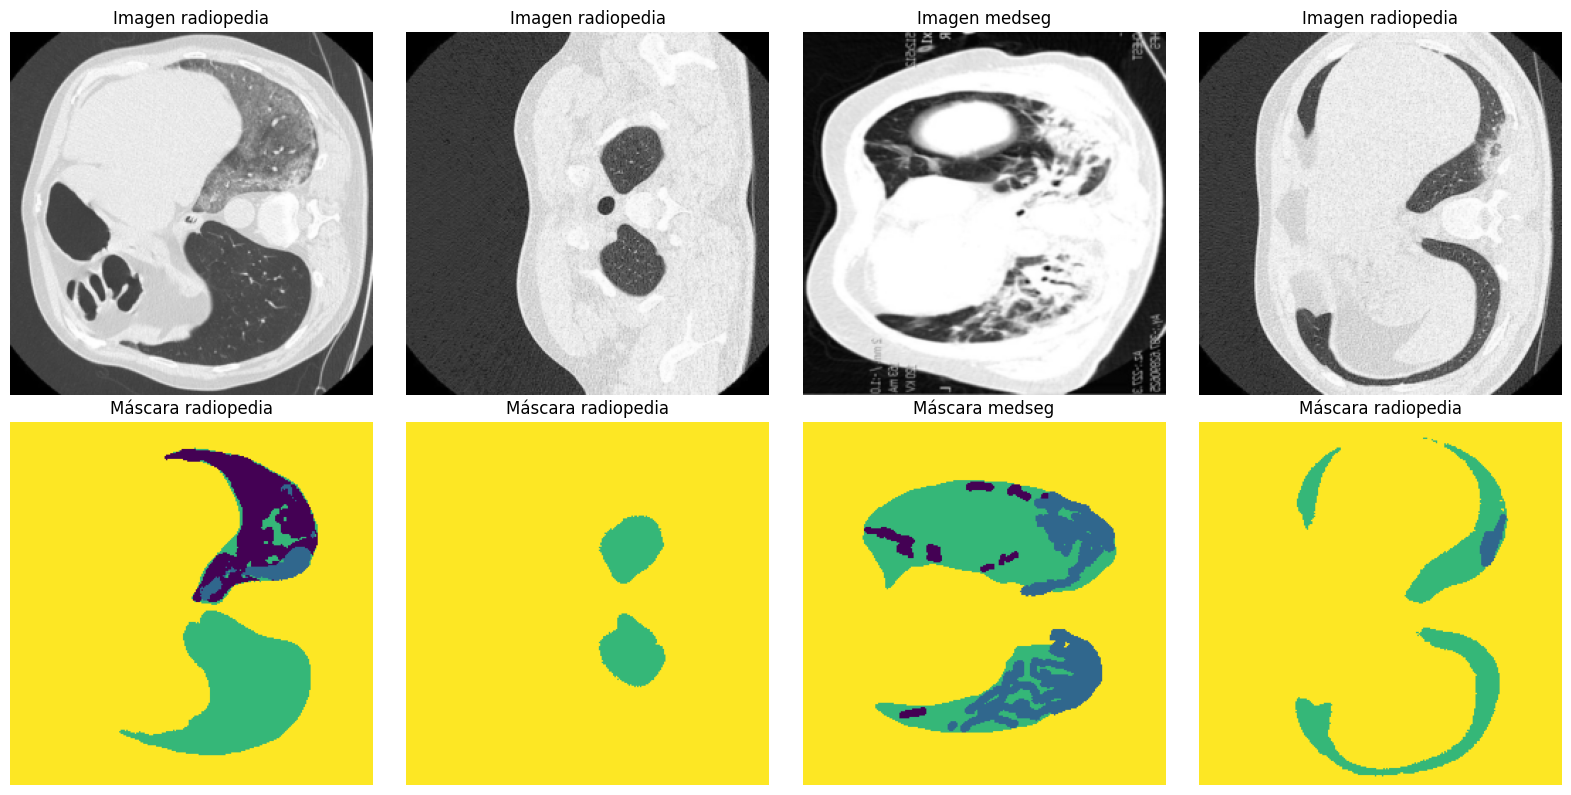

In [15]:
def cargar_npz(nombre_archivo):
    with np.load(ruta_procesado / nombre_archivo, allow_pickle=False) as datos:
        imagen = datos["imagen"]
        mascara = datos["mascara"] if "mascara" in datos.files else None
    return imagen, mascara

def mostrar_ejemplo(ax_img, ax_msk, imagen, mascara, titulo=""):
    ax_img.imshow(imagen[..., 0], cmap="gray")
    ax_img.set_title(f"Imagen {titulo}")
    ax_img.axis("off")
    if mascara is not None:
        etiqueta = np.argmax(mascara, axis=-1)
        ax_msk.imshow(etiqueta, cmap="viridis", vmin=0, vmax=3)
        ax_msk.set_title(f"Máscara {titulo}")
    ax_msk.axis("off")

etiquetados = manifiesto[manifiesto.fuente != "prueba"].sample(4, random_state=SEMILLA)
fig, ejes = plt.subplots(2, 4, figsize=(16, 8))
for col, fila in enumerate(etiquetados.itertuples()):
    imagen, mascara = cargar_npz(fila.archivo)
    mostrar_ejemplo(ejes[0, col], ejes[1, col], imagen, mascara, fila.fuente)
plt.tight_layout()
plt.show()

El fondo domina la imagen, mientras que `Consolidación` es, con diferencia, la clase minoritaria. Este desequilibrio es la razón principal por la que usaremos una pérdida combinada Dice + entropía cruzada. Dice es menos sensible al desequilibrio de clases que la entropía cruzada sola, porque optimiza directamente el traslape entre predicción y ground truth en vez de la precisión píxel a píxel.

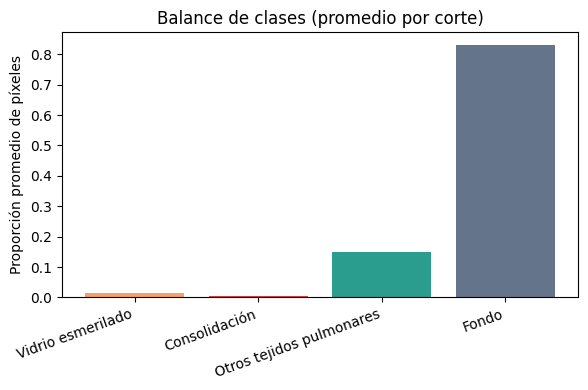

,proporción_promedio
Vidrio esmerilado,0.0140
Consolidación,0.0045
Otros tejidos pulmonares,0.1509
Fondo,0.8306


In [16]:
cols_prop = [f"proporcion_final_{i}" for i in range(4)]
promedio_clases = manifiesto.loc[manifiesto.fuente != "prueba", cols_prop].mean()
promedio_clases.index = clases

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(clases, promedio_clases.values, color=colores)
ax.set_ylabel("Proporción promedio de píxeles")
ax.set_title("Balance de clases (promedio por corte)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
display(promedio_clases.to_frame("proporción_promedio"))

#### Detección de volúmenes en radiopedia

El dataset no trae id de paciente, pero los 829 cortes de radiopedia son cortes consecutivos de unos pocos volúmenes de tomografía. Cortes vecinos del mismo volumen son casi idénticos (correlación > 0.9). Si se reparten al azar entre entrenamiento y validación, el modelo "ya vio" la imagen de validación y la métrica sale inflada. Para evitarlo se calcula la correlación de Pearson entre cada corte de radiopedia y el siguiente, donde la correlación cae por debajo de `UMBRAL_VOLUMEN = 0.8` empieza otro volumen. Cada corte de medseg es su propio volumen (la correlación mediana entre vecinos de medseg es ≈0.2: son cortes independientes).

#### Partición entrenamiento / validación / prueba

- Radiopedia se reparte por volumen completo a 80 / 10 / 10 %.
- Medseg se barajea y se divide 70 / 15 / 15 %. Se le da más peso porque es la misma fuente que el conjunto de prueba de Kaggle.
- La partición de prueba interna se aparta y no se toca hasta la evaluación final.

#### Aumento de datos

Solo sobre entrenamiento y solo en la configuración refinada se eligen transformaciones que producen imágenes que sí podrían aparecer en un CT axial real:

- Volteo horizontal (p = 0.5) ya que los pulmones son aproximadamente simétricos.
- Rotación ±10° y escala 0.9–1.1 con la misma transformación afín para imagen y máscara.
- Gamma aleatoria 0.8–1.25 sobre la imagen. Como el ETL normalizó cada corte a su propio mínimo y máximo, las unidades Hounsfield ya no se conservan y el contraste varía de corte a corte; este aumento hace al modelo tolerante a esa variación.

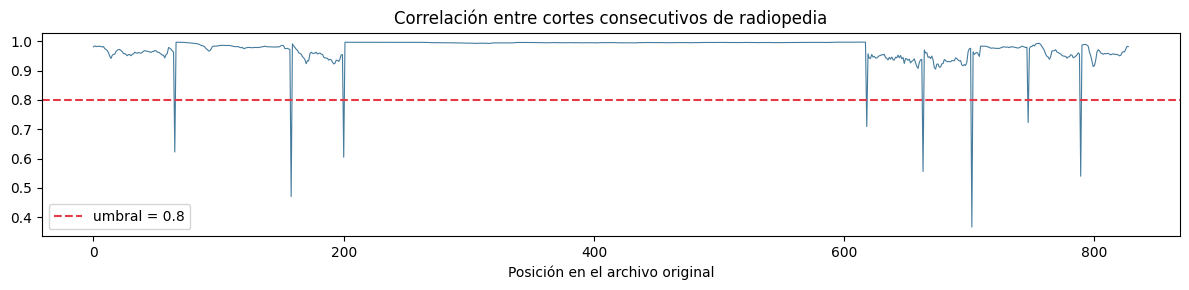

Volúmenes detectados en radiopedia: 9


particion,test,train,val,All
fuente,,,,
medseg,15,70,15,100
radiopedia,81,664,84,829
All,96,734,99,929


Entrenamiento: 734 | Validación: 99 | Prueba interna: 96 | Prueba oficial Kaggle: 10


In [17]:
manifiesto = pd.read_csv(ruta_procesado / "manifiesto.csv")
etiquetados_df = manifiesto[manifiesto.fuente != "prueba"].reset_index(drop=True)
df_test_oficial = manifiesto[manifiesto.fuente == "prueba"].sort_values("indice")

# Cargar todo en memoria (≈300 MB): evita leer disco en cada época
imagenes = np.empty((len(etiquetados_df), *TAMANO), dtype=np.float32)
mascaras = np.empty((len(etiquetados_df), *TAMANO), dtype=np.uint8)
for pos, archivo in enumerate(etiquetados_df.archivo):
    imagen, mascara = cargar_npz(archivo)
    imagenes[pos], mascaras[pos] = imagen[..., 0], mascara.argmax(-1)

# --- Detección de volúmenes en radiopedia por correlación entre cortes consecutivos
radiopedia = (etiquetados_df.fuente == "radiopedia").to_numpy()
orden = etiquetados_df[radiopedia].sort_values("indice").index.to_numpy()
planas = imagenes[orden].reshape(len(orden), -1).astype(np.float64)
planas = (planas - planas.mean(1, keepdims=True)) / planas.std(1, keepdims=True)
correlacion = (planas[:-1] * planas[1:]).mean(1)
UMBRAL_VOLUMEN = 0.8
inicios = np.where(correlacion < UMBRAL_VOLUMEN)[0] + 1
volumen = np.zeros(len(etiquetados_df), dtype=int)
volumen[orden] = np.cumsum(np.isin(np.arange(len(orden)), inicios))
volumen[~radiopedia] = np.arange((~radiopedia).sum()) + volumen.max() + 1
etiquetados_df["volumen"] = volumen

plt.figure(figsize=(12, 3))
plt.plot(correlacion, lw=0.8, color="#457b9d")
plt.axhline(UMBRAL_VOLUMEN, color="#e63946", ls="--", label=f"umbral = {UMBRAL_VOLUMEN}")
plt.title("Correlación entre cortes consecutivos de radiopedia")
plt.xlabel("Posición en el archivo original")
plt.legend()
plt.tight_layout()
plt.show()
print("Volúmenes detectados en radiopedia:", etiquetados_df[radiopedia].volumen.nunique())

# --- Partición por volumen (radiopedia) y por corte barajado (medseg)
objetivos = {"train": 0.8, "val": 0.1, "test": 0.1}
tamanos = etiquetados_df[radiopedia].groupby("volumen").size().sort_values(ascending=False)
asignacion, acumulado = {}, dict.fromkeys(objetivos, 0)
for vol, n in tamanos.items():
    faltante = {p: objetivos[p] - acumulado[p] / tamanos.sum() for p in objetivos}
    p = max(faltante, key=faltante.get)
    asignacion[vol] = p
    acumulado[p] += n
etiquetados_df["particion"] = etiquetados_df.volumen.map(asignacion)

medseg = np.random.RandomState(SEMILLA).permutation(etiquetados_df.index[etiquetados_df.fuente == "medseg"].to_numpy())
cortes_medseg = np.split(medseg, [int(0.7 * len(medseg)), int(0.85 * len(medseg))])
for p, posiciones in zip(objetivos, cortes_medseg):
    etiquetados_df.loc[posiciones, "particion"] = p

assert etiquetados_df.particion.notna().all()
assert etiquetados_df.groupby("volumen").particion.nunique().max() == 1, "Un volumen quedó en dos particiones"
indices = {p: etiquetados_df.index[etiquetados_df.particion == p].to_numpy() for p in objetivos}
display(pd.crosstab(etiquetados_df.fuente, etiquetados_df.particion, margins=True))


# --- Dataset con aumentos realistas para CT axial
def aumentar(imagen, mascara):
    if torch.rand(1) < 0.5:
        imagen, mascara = imagen.flip(-1), mascara.flip(-1)
    angulo = torch.empty(1).uniform_(-10, 10).item() * math.pi / 180
    escala = torch.empty(1).uniform_(0.9, 1.1).item()
    c, s = math.cos(angulo) / escala, math.sin(angulo) / escala
    theta = torch.tensor([[[c, -s, 0.0], [s, c, 0.0]]])
    malla = F.affine_grid(theta, (1, 1, *TAMANO), align_corners=False)
    imagen = F.grid_sample(imagen[None], malla, mode="bilinear", padding_mode="border", align_corners=False)[0]
    mascara = F.grid_sample(mascara[None, None].float(), malla, mode="nearest", padding_mode="border", align_corners=False)[0, 0].long()
    gamma = torch.empty(1).uniform_(0.8, 1.25).item()
    return imagen.clamp(0, 1) ** gamma, mascara


class DatasetSegmentacion(Dataset):
    def __init__(self, posiciones, aumentar=False):
        self.posiciones, self.aumentar = posiciones, aumentar

    def __len__(self):
        return len(self.posiciones)

    def __getitem__(self, idx):
        pos = self.posiciones[idx]
        imagen = torch.from_numpy(imagenes[pos])[None]          # (1, H, W)
        mascara = torch.from_numpy(mascaras[pos]).long()        # (H, W) índices de clase
        return aumentar(imagen, mascara) if self.aumentar else (imagen, mascara)


TAMANO_LOTE = 16


def cargador(particion, aumentos=False, barajar=False):
    return DataLoader(DatasetSegmentacion(indices[particion], aumentos), batch_size=TAMANO_LOTE,
                      shuffle=barajar, num_workers=0, drop_last=barajar)


print(f"Entrenamiento: {len(indices['train'])} | Validación: {len(indices['val'])} | "
      f"Prueba interna: {len(indices['test'])} | Prueba oficial Kaggle: {len(df_test_oficial)}")

### Arquitectura U-Net

Elegimos U-Net (Ronneberger et al., 2015) porque es el estándar de facto para segmentación de imágenes médicas, su ruta de contracción extrae características a distintas escalas, su ruta de expansión reconstruye la resolución espacial original, y las conexiones de salto entre encoder y decoder recuperan el detalle fino de bordes que se pierde durante el downsampling.

Cada bloque convolucional usa `Conv2d → BatchNorm → ReLU` doble, seguido de
`MaxPool2d` en el encoder o `ConvTranspose2d` en el decoder. La capa final es una
convolución `1×1` que produce 4 mapas de logits (uno por clase), sobre los que
aplicamos `softmax` a lo largo del canal.

### Modificaciones sobre la arquitectura base

Se agrega:

- Batch Normalization después de cada convolución, para estabilizar y acelerar el
  entrenamiento.
- Padding "same" en las convoluciones (en vez de *valid*), para que la salida
  conserve el tamaño 256×256 sin necesitar recorte de las máscaras.
- `Dropout2d` en el cuello de botella y en los dos niveles más profundos del decodificador, como regularización dado que nuestro conjunto de entrenamiento es pequeño para un modelo convolucional profundo.La probabilidad se pasa como argumento: 0 en la configuración base y 0.2 en la refinada, para poder medir su efecto.


In [18]:
class BloqueConv(nn.Module):
    def __init__(self, canales_entrada, canales_salida, dropout=0.0):
        super().__init__()
        capas = [
            nn.Conv2d(canales_entrada, canales_salida, 3, padding=1, bias=False),
            nn.BatchNorm2d(canales_salida),
            nn.ReLU(inplace=True),
            nn.Conv2d(canales_salida, canales_salida, 3, padding=1, bias=False),
            nn.BatchNorm2d(canales_salida),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            capas.append(nn.Dropout2d(dropout))
        self.bloque = nn.Sequential(*capas)

    def forward(self, x):
        return self.bloque(x)


class UNet(nn.Module):
    def __init__(self, canales_entrada=1, num_clases=4, base=32, dropout=0.0):
        super().__init__()
        self.enc1 = BloqueConv(canales_entrada, base)
        self.enc2 = BloqueConv(base, base * 2)
        self.enc3 = BloqueConv(base * 2, base * 4)
        self.enc4 = BloqueConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.cuello = BloqueConv(base * 8, base * 16, dropout)

        self.subir4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = BloqueConv(base * 16, base * 8, dropout)
        self.subir3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = BloqueConv(base * 8, base * 4, dropout)
        self.subir2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = BloqueConv(base * 4, base * 2)
        self.subir1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = BloqueConv(base * 2, base)

        self.salida = nn.Conv2d(base, num_clases, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        c = self.cuello(self.pool(e4))

        d4 = self.dec4(torch.cat([self.subir4(c), e4], dim=1))
        d3 = self.dec3(torch.cat([self.subir3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.subir2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.subir1(d2), e1], dim=1))
        return self.salida(d1)  # logits (N, 4, H, W)


n_parametros = sum(p.numel() for p in UNet().parameters() if p.requires_grad)
print(f"Parámetros entrenables: {n_parametros:,}")

Parámetros entrenables: 7,762,564


### Entrenamiento

Se entrenan **dos variantes de la misma U-Net**, con la misma partición, la misma semilla y los mismos hiperparámetros, lo que cambia es la regularización.

| | `base` | `refinada` |
|---|---|---|
| Aumento de datos | no | sí |
| Dropout | 0 | 0.2 |
| Decaimiento de pesos (L2) | 0 | 1e-4 |
| Pérdida | entropía cruzada | 0.5 · Dice + 0.5 · entropía cruzada |

### Función de pérdida
La entropía cruzada da una señal de gradiente estable desde el inicio. El término Dice compensa el desequilibrio de clases, optimiza directamente el traslape entre predicción y ground truth en vez de la exactitud píxel a píxel, así que no se puede bajar prediciendo fondo casi siempre.

### Optimizador
AdamW como optimizador con tasa inicial `1e-3`. En la configuración refinada se activa el
decaimiento de pesos (`weight_decay = 1e-4`), que es la regularización L2 del
optimizador.

### Épocas y tamaño de lote
Tamaño de lote 16, máximo 60 épocas, paro temprano con paciencia 10 sobre `f1_lesion` de validación. Se guarda el mejor checkpoint y se recarga al final.

In [19]:
def perdida_dice(logits, objetivo, suavizado=1.0):
    probs = F.softmax(logits, dim=1)
    objetivo_1h = F.one_hot(objetivo, logits.shape[1]).permute(0, 3, 1, 2).float()
    interseccion = (probs * objetivo_1h).sum((0, 2, 3))
    union = probs.sum((0, 2, 3)) + objetivo_1h.sum((0, 2, 3))
    return 1 - ((2 * interseccion + suavizado) / (union + suavizado)).mean()


@torch.no_grad()
def evaluar(modelo, dl):
    """Dice e IoU por clase sobre la matriz de confusión acumulada de toda la partición."""
    modelo.eval()
    matriz = torch.zeros(4, 4, dtype=torch.long)
    perdida_ce = 0.0
    for im, ms in dl:
        im, ms = im.to(dispositivo), ms.to(dispositivo)
        logits = modelo(im)
        perdida_ce += F.cross_entropy(logits, ms).item() * len(im)
        matriz += torch.bincount((ms * 4 + logits.argmax(1)).flatten().cpu(), minlength=16).view(4, 4)
    matriz = matriz.double()
    vp = matriz.diag()
    pred, real = matriz.sum(0), matriz.sum(1)
    dice = 2 * vp / (pred + real).clamp(min=1)
    iou = vp / (pred + real - vp).clamp(min=1)
    return {"perdida_ce": perdida_ce / len(dl.dataset), "dice": dice.numpy(), "iou": iou.numpy(),
            "f1_lesion": float(dice[:2].mean()), "matriz": matriz.numpy()}

In [20]:
MAX_EPOCAS = 60
PACIENCIA_EARLY_STOPPING = 10
CONFIGURACIONES = {
    "base":     dict(aumentos=False, dropout=0.0, decaimiento=0.0,  peso_dice=0.0),
    "refinada": dict(aumentos=True,  dropout=0.2, decaimiento=1e-4, peso_dice=0.5),
}


def entrenar(nombre, cfg):
    torch.manual_seed(SEMILLA)
    modelo = UNet(dropout=cfg["dropout"]).to(dispositivo)
    optimizador = torch.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=cfg["decaimiento"])
    programador = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode="max", factor=0.5, patience=4)
    dl_train = cargador("train", aumentos=cfg["aumentos"], barajar=True)
    dl_val = cargador("val")
    ruta_ckpt = Path(f"mejor_modelo_{nombre}.pt")
    mejor, sin_mejora, historial = -1.0, 0, []
    peso_ce = 1.0 - cfg["peso_dice"]

    for epoca in range(1, MAX_EPOCAS + 1):
        modelo.train()
        inicio, acumulada = time.time(), 0.0
        for im, ms in dl_train:
            im, ms = im.to(dispositivo), ms.to(dispositivo)
            optimizador.zero_grad(set_to_none=True)
            logits = modelo(im)
            perdida = peso_ce * F.cross_entropy(logits, ms)
            if cfg["peso_dice"]:
                perdida = perdida + cfg["peso_dice"] * perdida_dice(logits, ms)
            perdida.backward()
            optimizador.step()
            acumulada += perdida.item() * len(im)
        m = evaluar(modelo, dl_val)
        programador.step(m["f1_lesion"])
        historial.append({"modelo": nombre, "epoca": epoca, "perdida_train": acumulada / len(dl_train.dataset),
                          "perdida_val_ce": m["perdida_ce"], "f1_lesion_val": m["f1_lesion"],
                          "dice_vidrio_val": m["dice"][0], "dice_consolidacion_val": m["dice"][1],
                          "lr": optimizador.param_groups[0]["lr"], "segundos": time.time() - inicio})
        print(f"{nombre:8s} Época {epoca:02d} | pérdida_train={historial[-1]['perdida_train']:.4f} | "
              f"CE_val={m['perdida_ce']:.4f} | f1_lesion_val={m['f1_lesion']:.4f} | {historial[-1]['segundos']:.0f} s")
        if m["f1_lesion"] > mejor:
            mejor, sin_mejora = m["f1_lesion"], 0
            torch.save(modelo.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= PACIENCIA_EARLY_STOPPING:
                print(f"{nombre}: early stopping en época {epoca} (mejor f1_lesion_val={mejor:.4f})")
                break
    modelo.load_state_dict(torch.load(ruta_ckpt, map_location=dispositivo))
    return modelo, pd.DataFrame(historial)


modelos, historiales = {}, []
for nombre, cfg in CONFIGURACIONES.items():
    modelos[nombre], h = entrenar(nombre, cfg)
    historiales.append(h)
historial = pd.concat(historiales, ignore_index=True)
historial.to_csv("historial.csv", index=False)

base     Época 01 | pérdida_train=0.7353 | CE_val=0.5197 | f1_lesion_val=0.0702 | 15 s
base     Época 02 | pérdida_train=0.3249 | CE_val=0.2589 | f1_lesion_val=0.1826 | 13 s
base     Época 03 | pérdida_train=0.1845 | CE_val=0.1742 | f1_lesion_val=0.2680 | 13 s
base     Época 04 | pérdida_train=0.1266 | CE_val=0.1790 | f1_lesion_val=0.0767 | 14 s
base     Época 05 | pérdida_train=0.0946 | CE_val=0.1548 | f1_lesion_val=0.2460 | 14 s
base     Época 06 | pérdida_train=0.0802 | CE_val=0.0932 | f1_lesion_val=0.3020 | 14 s
base     Época 07 | pérdida_train=0.0673 | CE_val=0.1601 | f1_lesion_val=0.2438 | 14 s
base     Época 08 | pérdida_train=0.0635 | CE_val=0.0800 | f1_lesion_val=0.4219 | 14 s
base     Época 09 | pérdida_train=0.0560 | CE_val=0.0775 | f1_lesion_val=0.3895 | 14 s
base     Época 10 | pérdida_train=0.0527 | CE_val=0.0731 | f1_lesion_val=0.4469 | 14 s
base     Época 11 | pérdida_train=0.0441 | CE_val=0.0790 | f1_lesion_val=0.3213 | 14 s
base     Época 12 | pérdida_train=0.0433 | 

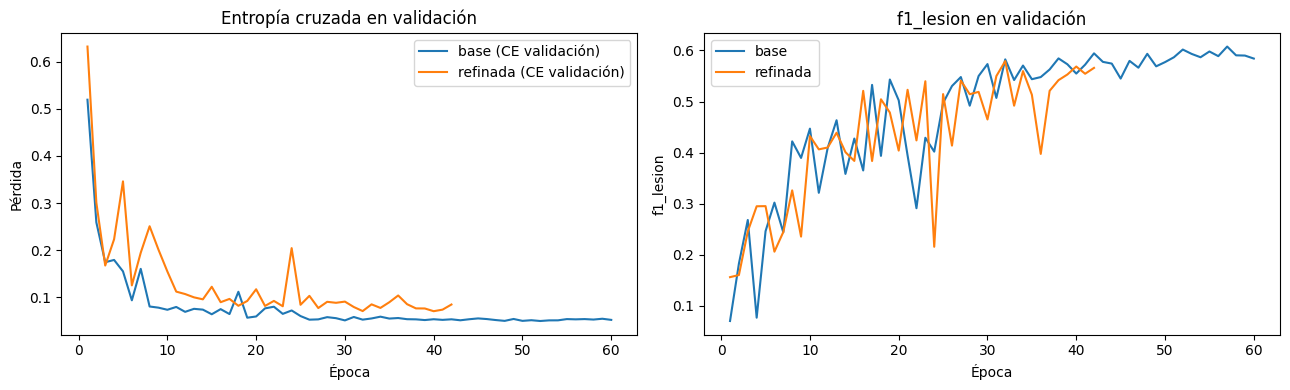

,epoca,perdida_train,perdida_val_ce,f1_lesion_val,dice_vidrio_val,dice_consolidacion_val
modelo,,,,,,
base,57,0.0194,0.0532,0.6076,0.6490,0.5662
refinada,32,0.0990,0.0703,0.5792,0.6291,0.5292


In [21]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
for nombre, g in historial.groupby("modelo"):
    ejes[0].plot(g.epoca, g.perdida_val_ce, label=f"{nombre} (CE validación)")
    ejes[1].plot(g.epoca, g.f1_lesion_val, label=nombre)
ejes[0].set(title="Entropía cruzada en validación", xlabel="Época", ylabel="Pérdida")
ejes[1].set(title="f1_lesion en validación", xlabel="Época", ylabel="f1_lesion")
for eje in ejes:
    eje.legend()
plt.tight_layout()
plt.show()
mejores = historial.loc[historial.groupby("modelo").f1_lesion_val.idxmax()].set_index("modelo")
display(mejores[["epoca", "perdida_train", "perdida_val_ce", "f1_lesion_val", "dice_vidrio_val", "dice_consolidacion_val"]])

Se utiliza coeficiente de Dice e Intersection over Union (IoU) por clase, y `f1_lesion`. A diferencia de la exactitud píxel a píxel, no se inflan cuando una clase domina la imagen.

Se evalúan los dos modelos, con sus mejores pesos, sobre validación y sobre la prueba que se apartó al inicio.

Dice             IoU             Dice
modelo                          base refinada   base refinada  mejora
val  Vidrio esmerilado        0.6490   0.6291 0.4804   0.4589 -0.0200
     Consolidación            0.5662   0.5292 0.3949   0.3598 -0.0370
     Otros tejidos pulmonares 0.9603   0.9628 0.9235   0.9282  0.0025
     Fondo                    0.9956   0.9954 0.9912   0.9909 -0.0002
     f1_lesion                0.6076   0.5792    NaN      NaN -0.0285
test Vidrio esmerilado        0.5763   0.7107 0.4048   0.5513  0.1344
     Consolidación            0.4940   0.3182 0.3280   0.1892 -0.1758
     Otros tejidos pulmonares 0.9453   0.9498 0.8963   0.9044  0.0045
     Fondo                    0.9936   0.9922 0.9873   0.9845 -0.0014
     f1_lesion                0.5352   0.5145    NaN      NaN -0.0207

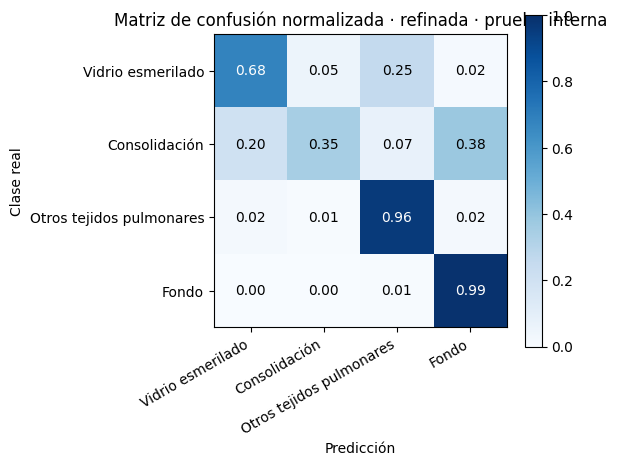

In [22]:
filas = []
for nombre, modelo in modelos.items():
    for particion in ["val", "test"]:
        m = evaluar(modelo, cargador(particion))
        for c, (d, j) in enumerate(zip(m["dice"], m["iou"])):
            filas.append({"modelo": nombre, "particion": particion, "clase": clases[c], "Dice": d, "IoU": j})
        filas.append({"modelo": nombre, "particion": particion, "clase": "f1_lesion", "Dice": m["f1_lesion"], "IoU": np.nan})
        if nombre == "refinada" and particion == "test":
            matriz_test = m["matriz"]

tabla = pd.DataFrame(filas)
tabla.to_csv("metricas.csv", index=False)
comparacion = tabla.pivot(index=["particion", "clase"], columns="modelo", values=["Dice", "IoU"])
comparacion = comparacion.reindex(pd.MultiIndex.from_product([["val", "test"], clases + ["f1_lesion"]]))
comparacion[("Dice", "mejora")] = comparacion[("Dice", "refinada")] - comparacion[("Dice", "base")]
display(comparacion.round(4))

normalizada = matriz_test / matriz_test.sum(1, keepdims=True)
plt.figure(figsize=(6, 5))
plt.imshow(normalizada, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(4), clases, rotation=30, ha="right")
plt.yticks(range(4), clases)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión normalizada · refinada · prueba interna")
for f in range(4):
    for c in range(4):
        plt.text(c, f, f"{normalizada[f, c]:.2f}", ha="center", va="center", color="white" if normalizada[f, c] > 0.5 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()

El modelo suele acertar bien la clase `Otros tejidos pulmonares` (contorno de pulmón sano) y `Fondo`, por ser regiones grandes y de alto contraste.
Los errores se concentran en los bordes entre `Vidrio esmerilado` y `Consolidación`, dos clases con intensidades de gris parecidas y transición gradual.
Lesiones muy pequeñas o difusas tienden a subestimarse (falsos negativos), un patrón común reportado también en la literatura de segmentación de COVID-19.

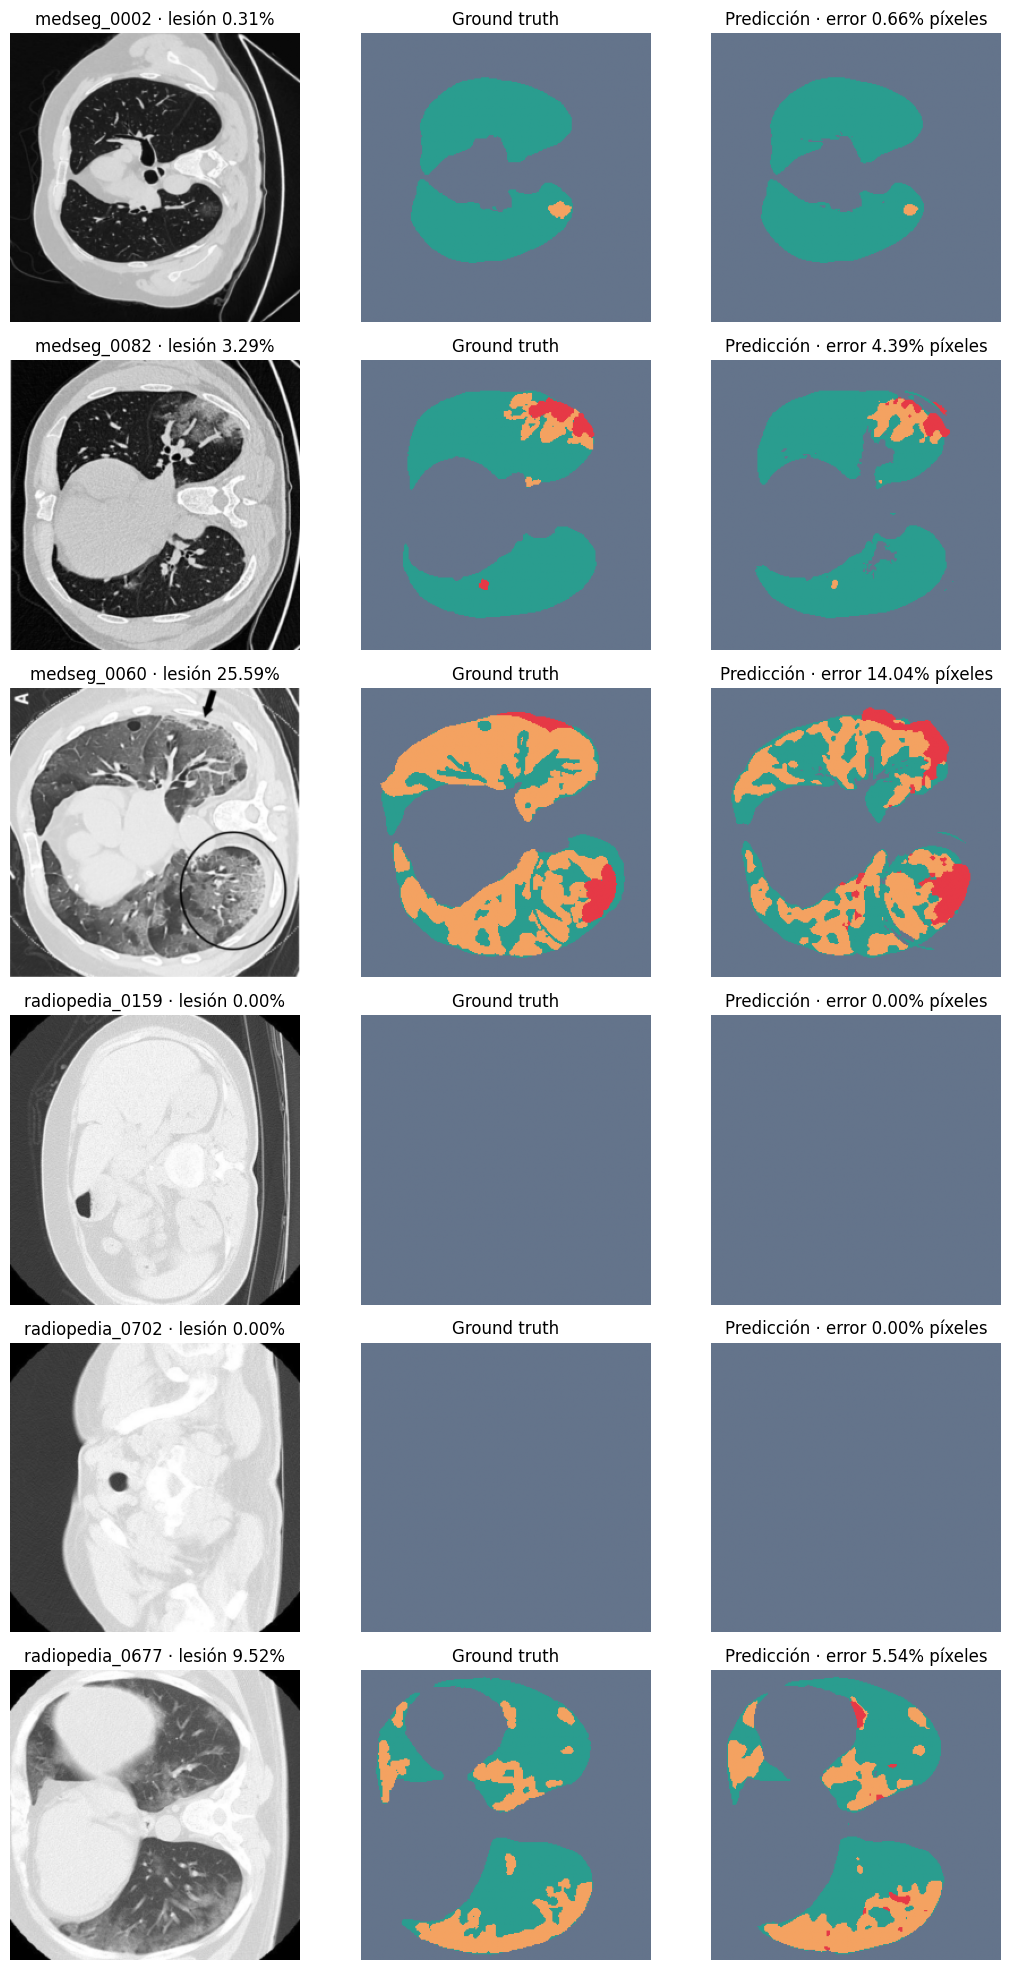

In [23]:
modelo = modelos["refinada"].eval()
test_df = etiquetados_df.loc[indices["test"]]
seleccion = []
for fuente, g in test_df.groupby("fuente"):
    ordenados = g.sort_values("proporcion_lesion")
    seleccion.extend(ordenados.index[np.unique([0, len(ordenados) // 2, len(ordenados) - 1])])

with torch.no_grad():
    preds = modelo(torch.from_numpy(imagenes[seleccion])[:, None].to(dispositivo)).argmax(1).cpu().numpy()

fig, ejes = plt.subplots(len(seleccion), 3, figsize=(11, 3.3 * len(seleccion)), squeeze=False)
for fila, pos, pred in zip(ejes, seleccion, preds):
    fila[0].imshow(imagenes[pos], cmap="gray", vmin=0, vmax=1)
    fila[1].imshow(mascaras[pos], cmap=ListedColormap(colores), vmin=0, vmax=3)
    fila[2].imshow(pred, cmap=ListedColormap(colores), vmin=0, vmax=3)
    fila[0].set_title(f"{etiquetados_df.id[pos]} · lesión {etiquetados_df.proporcion_lesion[pos]:.2%}")
    fila[1].set_title("Ground truth")
    fila[2].set_title(f"Predicción · error {(pred != mascaras[pos]).mean():.2%} píxeles")
    for eje in fila:
        eje.axis("off")
plt.tight_layout()
plt.show()

In [24]:
modelo = modelos["refinada"].eval()
imagenes_oficial = np.stack([cargar_npz(a)[0][..., 0] for a in df_test_oficial.archivo]).astype(np.float32)
with torch.no_grad():
    logits = modelo(torch.from_numpy(imagenes_oficial)[:, None].to(dispositivo))
    probs = F.interpolate(F.softmax(logits, dim=1), size=(512, 512), mode="bilinear", align_corners=False)
pred_oficial = probs.argmax(1).cpu().numpy()                                   # (10, 512, 512)
mascaras_envio = np.stack([pred_oficial == 0, pred_oficial == 1], axis=-1).astype(np.uint8)   # (10, 512, 512, 2)

envio = pd.DataFrame({"Id": np.arange(mascaras_envio.size), "Expected": mascaras_envio.ravel()})
envio.to_csv("submission.csv", index=False)
assert len(envio) == 10 * 512 * 512 * 2
print("Forma del envío:", mascaras_envio.shape, "· filas:", len(envio))
display(pd.DataFrame({"corte": df_test_oficial.id.to_numpy(),
                      "vidrio_esmerilado_%": mascaras_envio[..., 0].mean((1, 2)) * 100,
                      "consolidacion_%": mascaras_envio[..., 1].mean((1, 2)) * 100}).set_index("corte").round(2))

Forma del envío: (10, 512, 512, 2) · filas: 5242880


,vidrio_esmerilado_%,consolidacion_%
corte,,
prueba_0000,0.7800,1.9800
prueba_0001,1.5000,3.4600
prueba_0002,7.2800,2.6300
prueba_0003,1.3600,9.0700
prueba_0004,0.7300,0.3400
prueba_0005,3.4200,0.0000
prueba_0006,0.5400,1.8200
prueba_0007,5.2200,4.4100
prueba_0008,0.5300,1.7100


## Conclusiones

**Fortalezas**
- Las conexiones de salto de la U-Net preservan el detalle fino necesario para lesiones pequeñas.
- La pérdida combinada Dice+CE maneja razonablemente el fuerte desequilibrio hacia la clase `Fondo`.
- El pipeline de datos reutiliza directamente el ETL, evitando duplicar lógica de limpieza y garantizando consistencia entre EDA y modelado.

**Debilidades**
- El conjunto de entrenamiento es pequeño para una red convolucional profunda; un backbone preentrenado (p. ej. ResNet en el encoder, transferencia desde ImageNet adaptada a 1 canal) podría mejorar la generalización.
- No se exploró validación cruzada por volumen; con solo 9 volúmenes en radiopedia, la métrica de validación depende de cuáles caen en cada partición.
- Se podría probar una pérdida focal para reforzar aún más el aprendizaje de la clase minoritaria `Consolidación`.
- Aumento de datos más agresivo (deformaciones elásticas, comunes en literatura de segmentación médica) podría ayudar dado el tamaño limitado del dataset.

**Desafíos** 

El principal desafío fue el desequilibrio de clases evidenciado en el EDA, que abordamos con la pérdida Dice en vez de depender solo de entropía cruzada; el segundo fue mantener la alineación exacta entre imagen y máscara al aplicar aumento de datos, lo que resolvimos aplicando siempre la mismatransformación geométrica a ambas simultáneamente.


## Referencias

- Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI 2015. https://arxiv.org/abs/1505.04597
- Milletari, F., Navab, N., & Ahmadi, S. A. (2016). *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation*. 3DV 2016. https://arxiv.org/abs/1606.04797 (referencia del uso de Dice Loss)
- Kaggle. *COVID-19 CT Segmentation competition*. https://www.kaggle.com/competitions/covid-segmentation
- Notebook de inicio de Kaggle sobre el que se basó la U-Net: https://www.kaggle.com/code/vimpsykal/unet-segmentation (U-Net en Keras sobre medseg; se reimplementó en PyTorch y se amplió con partición por volumen,aumentos, pérdida Dice y envío).
- Notebook de inicio del equipo: `etl_eda.ipynb` (limpieza y transformación del
  conjunto de datos, elaborado por el equipo)